In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

In [4]:
load_dotenv()
llm_model = ChatOpenAI()

In [5]:
class cricState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [6]:
def calc_sr(state: cricState):
    sr = (state['runs']/state['balls'])*100
    state['sr'] = sr
    return {'sr' : sr}

In [7]:
def calc_bpb(state: cricState):

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}

In [8]:
def calc_boundary_percent(state: cricState):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}

In [9]:
def summary(state: cricState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'summary': summary}

In [11]:
cric_graph = StateGraph(cricState)

cric_graph.add_node('calc_sr',calc_sr)
cric_graph.add_node('calc_bpb',calc_bpb)
cric_graph.add_node('calc_boundary_percent',calc_boundary_percent)
cric_graph.add_node('summary',summary)

cric_graph.add_edge(START,'calc_sr')
cric_graph.add_edge(START,'calc_bpb')
cric_graph.add_edge(START,'calc_boundary_percent')

cric_graph.add_edge('calc_sr','summary')
cric_graph.add_edge('calc_bpb','summary')
cric_graph.add_edge('calc_boundary_percent','summary')

cric_graph.add_edge('summary',END)


workflow = cric_graph.compile()

In [12]:
initial_state = {'runs':149, 'balls':72, 'fours':10, 'sixes':6}

final_State = workflow.invoke(initial_state)

print(final_State)

{'runs': 149, 'balls': 72, 'fours': 10, 'sixes': 6, 'sr': 206.94444444444446, 'bpb': 4.5, 'boundary_percent': 51.006711409395976, 'summary': '\nStrike Rate - 206.94444444444446 \n\nBalls per boundary - 4.5 \n\nBoundary percent - 51.006711409395976\n'}


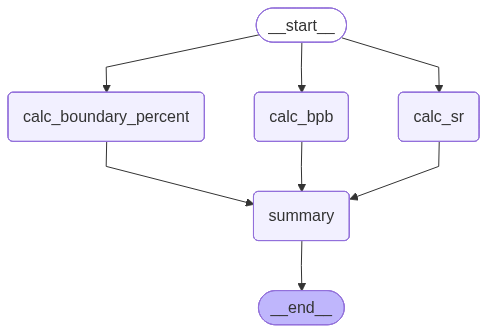

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())